# Red Centinela - deteccion de trafico de red con machine learning

**Proyecto:** Red Centinela  |  **Materia:** Gestion de Proyectos  |  **UAEMex** - 9no semestre

Este cuaderno reproduce de principio a fin el **modulo M2 (motor de deteccion)** usando el
mismo codigo que esta en el repositorio [`anorak1212/red-centinela`](https://github.com/anorak1212/red-centinela):

1. Descarga del dataset NSL-KDD (`KDDTrain+` / `KDDTest+`)
2. Exploracion y preprocesamiento: one-hot de categoricas + estandarizacion, 122 caracteristicas
3. Entrenamiento de cuatro modelos: Random Forest, LinearSVC, KNN e Isolation Forest
4. Calibracion del umbral del ensamble sobre un holdout estratificado
5. Evaluacion sobre `KDDTest+` (macro-F1, AUC-ROC, recall por familia) con graficas
6. Demo de prediccion en vivo

**Tiempo estimado:** 5 a 8 minutos en una sesion gratuita de Colab.
**Reproducibilidad:** `RANDOM_STATE = 42` en todas las estimaciones, asi que los numeros
que ves aqui deben coincidir con los del repositorio.

## 0. Entorno

In [1]:
import os
import subprocess
import sys
from pathlib import Path

# En Colab no hay repo: lo clona. Si ya estas dentro del repo, no hace nada.
if Path("motor").exists():
    RAIZ = Path.cwd()
    print("Ya estas dentro del repositorio:", RAIZ)
else:
    subprocess.check_call(
        ["git", "clone", "--depth", "1", "https://github.com/anorak1212/red-centinela.git"]
    )
    os.chdir("red-centinela")
    RAIZ = Path.cwd()
    print("Repositorio clonado en:", RAIZ)

if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

Ya estas dentro del repositorio: C:\Users\mateo\Downloads\RedCentinela\red-centinela


In [2]:
import importlib.util

DEPENDENCIAS = [
    "sklearn", "pandas", "numpy", "joblib", "matplotlib",
    "fastapi", "uvicorn", "streamlit", "requests",
]
faltan = [m for m in DEPENDENCIAS if importlib.util.find_spec(m) is None]

if faltan:
    print("Instalando dependencias:", ", ".join(faltan))
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt", "matplotlib"]
    )
else:
    print("Todas las dependencias ya estan instaladas.")

Todas las dependencias ya estan instaladas.


## 1. Dataset NSL-KDD

NSL-KDD es el dataset publico estandar para deteccion de intrusos. El crudo no se versiona
en git (pesa ~24 MB), asi que el script `scripts/download_nslkdd.py` lo repone desde un espejo
publico. `KDDTrain+` sirve para entrenar y `KDDTest+` es el conjunto de prueba oficial:
contiene ataques que **no** estan en el entrenamiento, por eso es tan exigente.

In [3]:
from scripts.download_nslkdd import main as descargar_datos

descargar_datos()

ya existe KDDTrain+.txt (19,109,424 bytes)
ya existe KDDTest+.txt (3,441,513 bytes)
ya existe KDDTrain+_20Percent.txt (3,822,033 bytes)


In [4]:
from motor.data import FEATURE_NAMES, TARGET, load_raw

train = load_raw("KDDTrain+.txt")
test = load_raw("KDDTest+.txt")

print(f"KDDTrain+ : {len(train):,} filas x {train.shape[1]} columnas")
print(f"KDDTest+  : {len(test):,} filas x {test.shape[1]} columnas")
print(f"Caracteristicas: {len(FEATURE_NAMES)} (3 categoricas + 38 numericas)")
train.head(3)

KDDTrain+ : 125,973 filas x 45 columnas
KDDTest+  : 22,544 filas x 45 columnas
Caracteristicas: 41 (3 categoricas + 38 numericas)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty,family,y_binary
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.0,0.0,0.0,0.05,0.0,normal,20,normal,0
1,0,udp,other,SF,146,0,0,0,0,0,...,0.88,0.0,0.0,0.0,0.00,0.0,normal,15,normal,0
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.00,0.0,1.0,1.0,0.00,0.0,neptune,19,dos,1


## 2. Exploracion

Dos datos importan aqui. Primero: las clases estan desbalanceadas (los ataques superan a lo
normal en el entrenamiento), lo que obliga a usar `class_weight="balanced"` y a calibrar el
umbral en vez de quedarse con 0.5. Segundo: en `KDDTest+` aparecen firmas de ataque que no
existen en `KDDTrain+` (apache2, mailbomb, xsnoop...), y eso es exactamente lo que despues
explica el hueco de rendimiento frente al criterio PERF-003.

Balance de clases (binario: 0 = normal, 1 = ataque):
y_binary
0    67343
1    58630

         KDDTrain+  KDDTest+
family                      
normal       67343      9711
dos          45927      7460
probe        11656      2421
r2l            995      2854
u2r             52        67
unknown          0        31



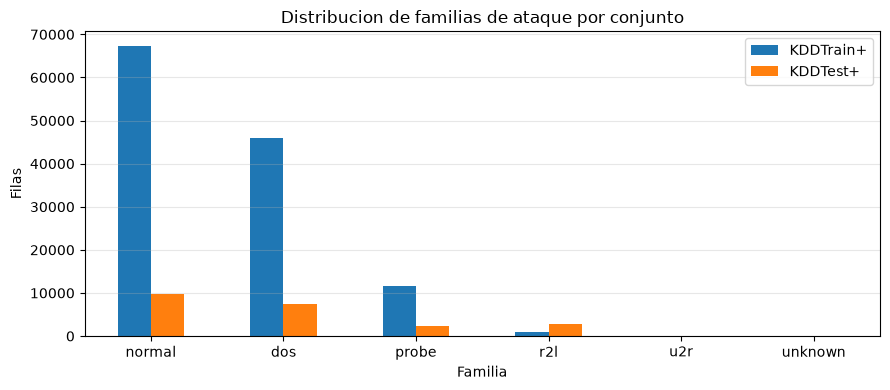

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

print("Balance de clases (binario: 0 = normal, 1 = ataque):")
print(train[TARGET].value_counts().to_string())
print()

familias = ["normal", "dos", "probe", "r2l", "u2r", "unknown"]
tabla = pd.DataFrame(
    {"KDDTrain+": train["family"].value_counts(),
     "KDDTest+": test["family"].value_counts()}
).reindex(familias).fillna(0).astype(int)
print(tabla.to_string())
print()

ax = tabla.plot(kind="bar", figsize=(9, 4), color=["#1f77b4", "#ff7f0e"])
ax.set_title("Distribucion de familias de ataque por conjunto")
ax.set_xlabel("Familia")
ax.set_ylabel("Filas")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Preprocesamiento

`Preprocessor` convierte cada registro en un vector de **122 caracteristicas**: one-hot de
`protocol_type`, `service` y `flag`, mas las 38 numericas estandarizadas con
`StandardScaler`. El detalle que evita el data leakage: el escalador y las categorias se
ajustan **solo con `KDDTrain+`** y luego se reutilizan identicos en `KDDTest+`. Ese mismo
objeto es el que se serializa con joblib y carga la API en produccion.

In [6]:
import time

from motor.preprocess import Preprocessor

t0 = time.time()
pp = Preprocessor()
Xtr = pp.fit_transform(train)
Xte = pp.transform(test)
ytr = train[TARGET].to_numpy()
yte = test[TARGET].to_numpy()

print(f"Matriz train: {Xtr.shape}   matriz test: {Xte.shape}")
print(f"Caracteristicas transformadas: {pp.n_features()}")
print(f"Tiempo de preprocesamiento: {time.time() - t0:.1f}s")

Matriz train: (125973, 122)   matriz test: (22544, 122)
Caracteristicas transformadas: 122
Tiempo de preprocesamiento: 0.8s


## 4. Entrenamiento

Cuatro modelos sobre el mismo preprocesado:

| Modelo | Tipo | Papel en el ensamble |
|---|---|---|
| Random Forest (300 arboles) | supervisado | voto principal, `predict_proba` |
| KNN (k=7) | supervisado | voto vecino, `predict_proba` |
| LinearSVC | supervisado | voto lineal, `decision_function` escalada a [0,1] |
| Isolation Forest | **no supervisado** | deteccion de anomalias aparte, sin etiquetas |

Los tres supervisados se combinan en un **ensamble suave** (promedio de probabilidades) con
un umbral calibrado por busqueda sobre un holdout estratificado del 25% del entrenamiento.
`motor.train` guarda todo en `motor/models/` con joblib y escribe `metadata.json`.

In [7]:
from motor.train import main as entrenar

t0 = time.time()
entrenar()
print(f"\nEntrenamiento completo en {(time.time() - t0) / 60:.1f} minutos")

train=125,973  test=22,544  ataques_train=58,630  ataques_test=12,833


matriz: (125973, 122)  preproceso en 3.1s
Calibrando umbral del ensamble sobre holdout...


  umbral calibrado=0.35  macro-F1 holdout=0.9984
Entrenando modelos finales...


  RandomForest OK  (91.6s)


  LinearSVC OK  (99.8s)
  KNN OK  (99.9s)


  IsolationForest OK  (102.3s)

Listo en 102.3s. Modelos en C:\Users\mateo\Downloads\RedCentinela\red-centinela\motor\models

Entrenamiento completo en 1.7 minutos


## 5. Evaluacion sobre KDDTest+

In [8]:
import json

from motor.evaluate import main as evaluar

evaluar()

metrics = json.loads(Path("motor/models/metrics.json").read_text(encoding="utf-8"))

ENSAMBLE (umbral 0.35)  acc=0.7881  macro-F1=0.7877  AUC=0.9652


Recall por familia (ensamble): {'dos': 0.8408, 'probe': 0.8116, 'r2l': 0.0375, 'u2r': 0.2388}


IFOREST  AUC=0.9376  recall@10%=0.9965

Holdout train (PERF-003): macro-F1=0.9984 -> OK


In [9]:
ens = metrics["ensamble"]
tabla = pd.DataFrame(
    {
        "metrica": [
            "Umbral de decision (calibrado)",
            "Accuracy en KDDTest+",
            "Macro-F1 binario en KDDTest+",
            "AUC-ROC en KDDTest+",
            "Macro-F1 en holdout de entrenamiento",
        ],
        "valor": [
            ens["umbral_decision"],
            ens["accuracy_test"],
            ens["macro_f1_binario_test"],
            ens["auc_roc_test"],
            metrics["macro_f1_holdout_train"],
        ],
    }
)
tabla["valor"] = tabla["valor"].astype(float).round(4)
tabla

,metrica,valor
0,Umbral de decision (calibrado),0.3500
1,Accuracy en KDDTest+,0.7881
2,Macro-F1 binario en KDDTest+,0.7877
3,AUC-ROC en KDDTest+,0.9652
4,Macro-F1 en holdout de entrenamiento,0.9984


## 6. Graficas de resultados

Las tres graficas de abajo son las que sustentan la evidencia del modulo M2: matriz de
confusion, curva ROC y recall por familia. Se guardan en `resultados_colab/` para poder
adjuntarlas en el informe.

In [10]:
import joblib
from motor.data import MODEL_DIR, ensure_processed
from motor.ensemble import predecir
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)

Xtec, yte = ensure_processed("test")
meta = json.loads((MODEL_DIR / "metadata.json").read_text(encoding="utf-8"))
rf = joblib.load(MODEL_DIR / "rf.joblib")
svm = joblib.load(MODEL_DIR / "svm.joblib")
knn = joblib.load(MODEL_DIR / "knn.joblib")

yhat, p = predecir(
    {"rf": rf, "svm": svm, "knn": knn},
    Xtec,
    meta["umbral_decision"],
    tuple(meta["svm_proba_scale"]),
)
print(f"Predicciones generadas: {len(yhat):,}   positivas: {int(yhat.sum()):,}")

Predicciones generadas: 22,544   positivas: 8,665


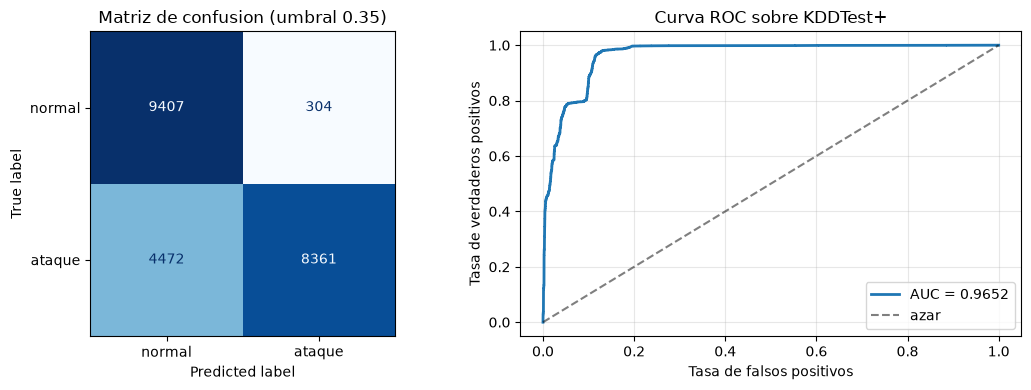

In [11]:
Path("resultados_colab").mkdir(exist_ok=True)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(
    confusion_matrix(yte, yhat), display_labels=["normal", "ataque"]
).plot(ax=ax[0], cmap="Blues", colorbar=False)
ax[0].set_title(f"Matriz de confusion (umbral {meta['umbral_decision']})")

fpr, tpr, _ = roc_curve(yte, p)
ax[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(yte, p):.4f}", linewidth=2)
ax[1].plot([0, 1], [0, 1], "k--", alpha=0.5, label="azar")
ax[1].set_xlabel("Tasa de falsos positivos")
ax[1].set_ylabel("Tasa de verdaderos positivos")
ax[1].set_title("Curva ROC sobre KDDTest+")
ax[1].legend(loc="lower right")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("resultados_colab/matriz_confusion_y_roc.png", dpi=150, bbox_inches="tight")
plt.show()

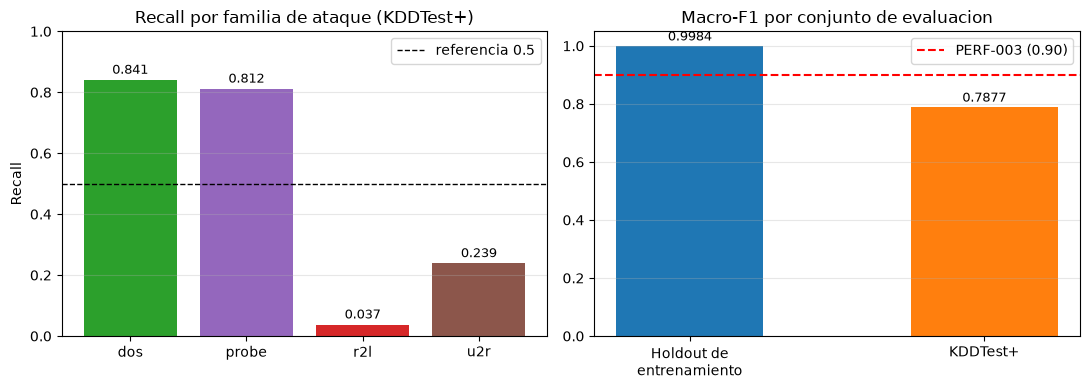

Recall por familia: {'dos': 0.8408, 'probe': 0.8116, 'r2l': 0.0375, 'u2r': 0.2388}


In [12]:
CODIGO_FAMILIA = {"dos": 1, "probe": 2, "r2l": 3, "u2r": 4}
yfam = (
    load_raw("KDDTest+.txt")["family"]
    .map({"normal": 0, **CODIGO_FAMILIA})
    .fillna(5)
    .astype(int)
    .to_numpy()
)

recalls = {}
for nombre, codigo in CODIGO_FAMILIA.items():
    sel = (yfam == codigo) & (yte == 1)
    recalls[nombre] = float(yhat[sel].mean()) if int(sel.sum()) else 0.0

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

barras = ax[0].bar(list(recalls), [round(v, 4) for v in recalls.values()],
                   color=["#2ca02c", "#9467bd", "#d62728", "#8c564b"])
ax[0].axhline(0.5, color="black", linestyle="--", linewidth=1, label="referencia 0.5")
ax[0].set_ylim(0, 1)
ax[0].set_title("Recall por familia de ataque (KDDTest+)")
ax[0].set_ylabel("Recall")
ax[0].legend()
ax[0].grid(axis="y", alpha=0.3)
for b, v in zip(barras, recalls.values()):
    ax[0].text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.3f}",
               ha="center", fontsize=9)

compara = {
    "Holdout de\nentrenamiento": metrics["macro_f1_holdout_train"],
    "KDDTest+": ens["macro_f1_binario_test"],
}
b2 = ax[1].bar(compara.keys(), compara.values(), color=["#1f77b4", "#ff7f0e"], width=0.5)
ax[1].axhline(0.90, color="red", linestyle="--", linewidth=1.5, label="PERF-003 (0.90)")
ax[1].set_ylim(0, 1.05)
ax[1].set_title("Macro-F1 por conjunto de evaluacion")
ax[1].legend()
ax[1].grid(axis="y", alpha=0.3)
for b, v in zip(b2, compara.values()):
    ax[1].text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.4f}",
               ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("resultados_colab/metricas_ensamble.png", dpi=150, bbox_inches="tight")
plt.show()

print("Recall por familia:", {k: round(v, 4) for k, v in recalls.items()})

## 7. Demo de prediccion

El mismo flujo que usa la API `POST /predict`: registro crudo -> `Preprocessor` -> promedio
del ensamble -> umbral calibrado. Se prueban registros reales de `KDDTest+`, uno normal y
uno de cada familia.

In [13]:
from motor.ensemble import proba_ensamble

pp_prod = joblib.load(MODEL_DIR / "preprocessor.joblib")
ESCALA = tuple(meta["svm_proba_scale"])


def predecir_registro(registro) -> float:
    """Probabilidad del ensamble para un registro NSL-KDD crudo (mismo flujo que /predict)."""
    df = pd.DataFrame([list(registro)], columns=FEATURE_NAMES)
    X = pp_prod.transform(df)
    return float(proba_ensamble(rf, svm, knn, X, ESCALA)[0])


casos = []
for familia_objetivo in ["normal", "dos", "probe", "r2l", "u2r"]:
    sel = test[test["family"] == familia_objetivo]
    if sel.empty:
        continue
    for _, fila in sel.head(2).iterrows():
        registro = fila[FEATURE_NAMES].to_numpy()
        casos.append(
            {
                "familia_real": familia_objetivo,
                "ataque_real": int(fila[TARGET]),
                "prob_ensamble": round(predecir_registro(registro), 4),
            }
        )

demo = pd.DataFrame(casos)
demo["prediccion"] = (demo["prob_ensamble"] >= meta["umbral_decision"]).astype(int)
demo["acierto"] = demo["prediccion"] == demo["ataque_real"]
demo

,familia_real,ataque_real,prob_ensamble,prediccion,acierto
0,normal,0,0.0452,0,True
1,normal,0,0.0446,0,True
2,dos,1,0.7161,1,True
3,dos,1,0.7156,1,True
4,probe,1,0.6976,1,True
5,probe,1,0.1492,0,False
6,r2l,1,0.0852,0,False
7,r2l,1,0.0746,0,False
8,u2r,1,0.2713,0,False
9,u2r,1,0.1382,0,False


## 8. Lo que no corre en Colab: API, tablero y alertas

Estas tres piezas viven en el repositorio y se ejecutan en local o en los servicios gratuitos
elegidos para el despliegue (Render / Neon / Streamlit Community Cloud):

```bash
# API REST con SQLite (docs en /docs de FastAPI)
uvicorn api.main:app --reload

# Tablero de monitoreo
streamlit run tablero/app.py

# Pruebas
python -m pytest -q

# Alertas de Telegram (requiere variables de entorno)
export TELEGRAM_BOT_TOKEN=...
export TELEGRAM_CHAT_ID=...
```

En Colab no tienen sentido: no hay puerto expuesto ni webhook alcanzable desde ahi. Lo que
si se puede validar aqui es el motor, que es justamente lo que la API invoca.

## 9. Resultado frente al criterio PERF-003

Aqui esta el punto incomodo del proyecto, y preferimos decirlo con la grafica encima antes
que maquillarlo:

- **En el holdout de entrenamiento el ensamble alcanza macro-F1 = 0.9984**, por encima del
  umbral de 0.90 que exige PERF-003.
- **En `KDDTest+` el ensamble queda en 0.7877**, por debajo.

La diferencia no es un bug de implementacion: `KDDTest+` contiene familias de ataque cuyas
firmas nunca se vieron en entrenamiento. El recall de R2L cae a 0.0375 y el de U2R a 0.2388,
mientras que DoS se sostiene en 0.84 y Probe en 0.81. La literatura reporta valores cercanos
a 0.80 como estado del arte sobre este mismo conjunto, asi que el proyecto esta en la zona
esperada, no por debajo de lo que cualquiera logra con estas tecnicas.

Lo que queda abierto y esta registrado como deuda tecnica en el acta de variaciones:
subir el recall de R2L/U2R (por ejemplo con aumento de datos o reponderacion mas agresiva)
o documentar el criterio con el dominio exacto al que aplica. Lo que no se va a hacer es
presentar dos entregables contradicitorios: el E6 ya reporta 0.7877 y hay que decir lo
mismo en todo lo demas.

## 10. Trazabilidad con el cronograma

Este cuaderno es la evidencia ejecutable de las actividades del EDT que trabajan el modulo
de deteccion:

| Actividad | Descripcion | Evidencia en este cuaderno |
|---|---|---|
| A22 | Adquisicion y preparacion del dataset NSL-KDD | Seccion 1: descarga y lectura |
| A23 | Pipeline de ingestion de vectores de trafico | Seccion 3: `Preprocessor` 122 features |
| A24 | Entrenamiento y evaluacion del modelo | Secciones 4, 5 y 6 (macro-F1 0.7877, criterio no cumplido) |
| A25 | Empaquetado del modelo en artefactos joblib | Seccion 4: `motor/models/*.joblib` |
| A26 | API REST de deteccion | Seccion 8: contrato de `POST /predict` (seccion 7 lo simula) |

Commits del repositorio: `e08b328` (andamiaje), `8add3ff` (motor + API), `fcd3a9e` (tablero),
`9db686e` (guia de uso).